In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
#Load dataset
df = pd.read_csv('changes-visitors-covid.csv')  


In [5]:
df.head()

,Entity,Code,Date,Retail & Recreation (%),Grocery & Pharmacy Stores (%),Residential (%),Transit Stations (%),Parks (%),Workplaces (%)
0,Afghanistan,AFG,"Feb 16, 2020",-9.0,-10.0,5.0,-2.0,0.0,-28.0
1,Afghanistan,AFG,"Feb 17, 2020",3.0,11.0,0.0,10.0,1.0,4.0
2,Afghanistan,AFG,"Feb 18, 2020",6.0,11.0,-1.0,9.0,2.0,5.0
3,Afghanistan,AFG,"Feb 19, 2020",3.0,5.0,-1.0,9.0,3.0,6.0
4,Afghanistan,AFG,"Feb 20, 2020",-1.0,3.0,1.0,0.0,1.0,5.0


In [6]:
# Basic info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17028 entries, 0 to 17027
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Entity                         17028 non-null  object 
 1   Code                           17028 non-null  object 
 2   Date                           17028 non-null  object 
 3   Retail & Recreation (%)        16872 non-null  float64
 4   Grocery & Pharmacy Stores (%)  16824 non-null  float64
 5   Residential (%)                16518 non-null  float64
 6   Transit Stations (%)           16893 non-null  float64
 7   Parks (%)                      16810 non-null  float64
 8   Workplaces (%)                 16980 non-null  float64
dtypes: float64(6), object(3)
memory usage: 1.2+ MB


In [7]:
df.describe()


,Retail & Recreation (%),Grocery & Pharmacy Stores (%),Residential (%),Transit Stations (%),Parks (%),Workplaces (%)
count,16872.000000,16824.000000,16518.000000,16893.000000,16810.000000,16980.000000
mean,-33.160740,-15.808428,12.691367,-36.428698,-13.904997,-25.236867
std,28.084099,22.833718,10.802297,27.530593,39.554419,25.258771
min,-98.000000,-98.000000,-16.000000,-100.000000,-100.000000,-92.000000
25%,-56.000000,-29.000000,3.000000,-59.000000,-39.000000,-45.000000
50%,-30.000000,-11.000000,12.000000,-38.000000,-15.000000,-24.000000
75%,-7.000000,1.000000,20.000000,-12.000000,2.000000,-2.000000
max,60.000000,76.000000,55.000000,37.000000,517.000000,80.000000


In [8]:
# data cleaning
df = df.drop_duplicates()


In [12]:
df.fillna(df.select_dtypes(include=np.number).mean(), inplace=True)

In [13]:
df.isnull().sum()

Entity                           0
Code                             0
Date                             0
Retail & Recreation (%)          0
Grocery & Pharmacy Stores (%)    0
Residential (%)                  0
Transit Stations (%)             0
Parks (%)                        0
Workplaces (%)                   0
dtype: int64

In [14]:
# Simple Analysis
print("Mean values:\n", df.mean(numeric_only=True))

Mean values:
 Retail & Recreation (%)         -33.160740
Grocery & Pharmacy Stores (%)   -15.808428
Residential (%)                  12.691367
Transit Stations (%)            -36.428698
Parks (%)                       -13.904997
Workplaces (%)                  -25.236867
dtype: float64


In [15]:
corr = df.corr(numeric_only=True)
print("\nCorrelation Matrix:\n", corr)


Correlation Matrix:
                                Retail & Recreation (%)  \
Retail & Recreation (%)                       1.000000   
Grocery & Pharmacy Stores (%)                 0.845431   
Residential (%)                              -0.853866   
Transit Stations (%)                          0.922270   
Parks (%)                                     0.593286   
Workplaces (%)                                0.853969   

                               Grocery & Pharmacy Stores (%)  Residential (%)  \
Retail & Recreation (%)                             0.845431        -0.853866   
Grocery & Pharmacy Stores (%)                       1.000000        -0.743742   
Residential (%)                                    -0.743742         1.000000   
Transit Stations (%)                                0.797865        -0.865310   
Parks (%)                                           0.582192        -0.578848   
Workplaces (%)                                      0.741541        -0.871113   

   

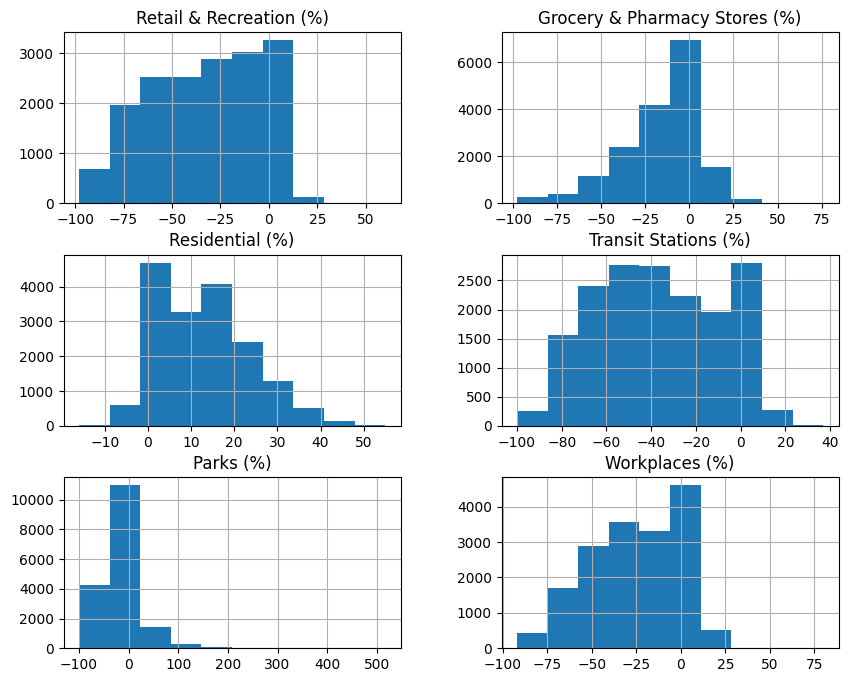

In [16]:
# Visualization
df.hist(figsize=(10,8))
plt.show()


In [17]:
import seaborn as sns


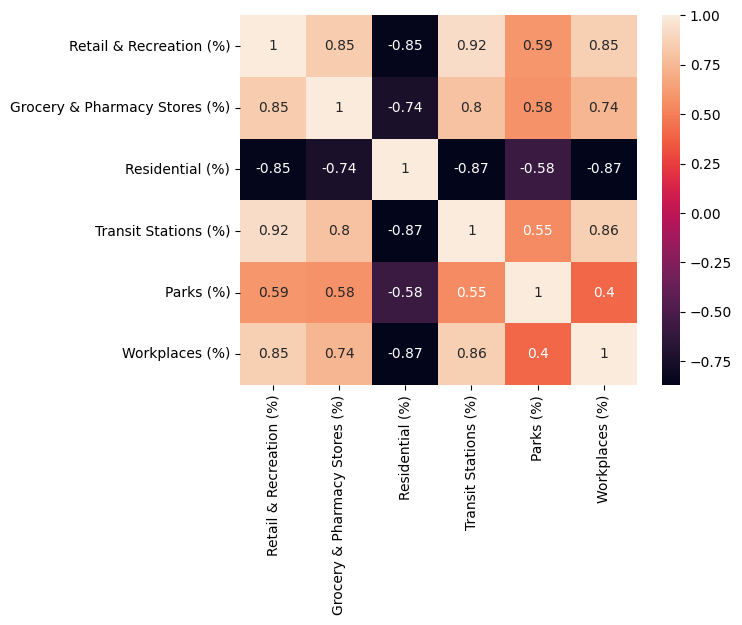

In [18]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [19]:
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [20]:
df_numeric = df.select_dtypes(include=np.number)


In [21]:
X = df_numeric.iloc[:, :-1]  
y = df_numeric.iloc[:, -1]    


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [24]:
y_pred = model.predict(X_test)

In [25]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 101.47193197665398


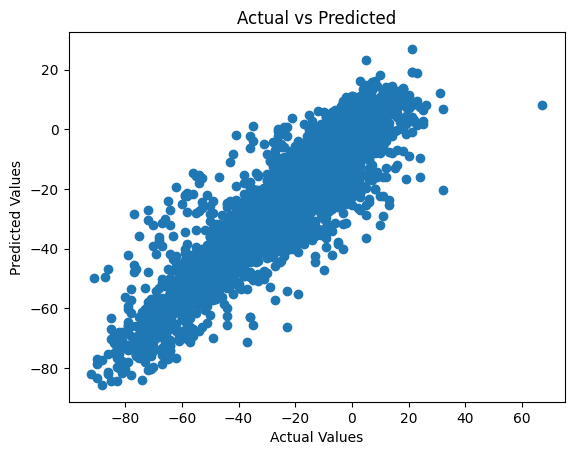

In [26]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()


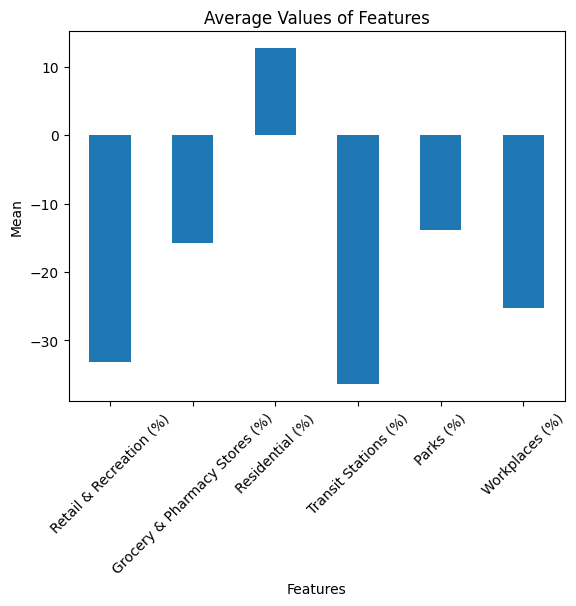

In [27]:
means = df.mean(numeric_only=True)

means.plot(kind='bar')
plt.title("Average Values of Features")
plt.xlabel("Features")
plt.ylabel("Mean")
plt.xticks(rotation=45)
plt.show()

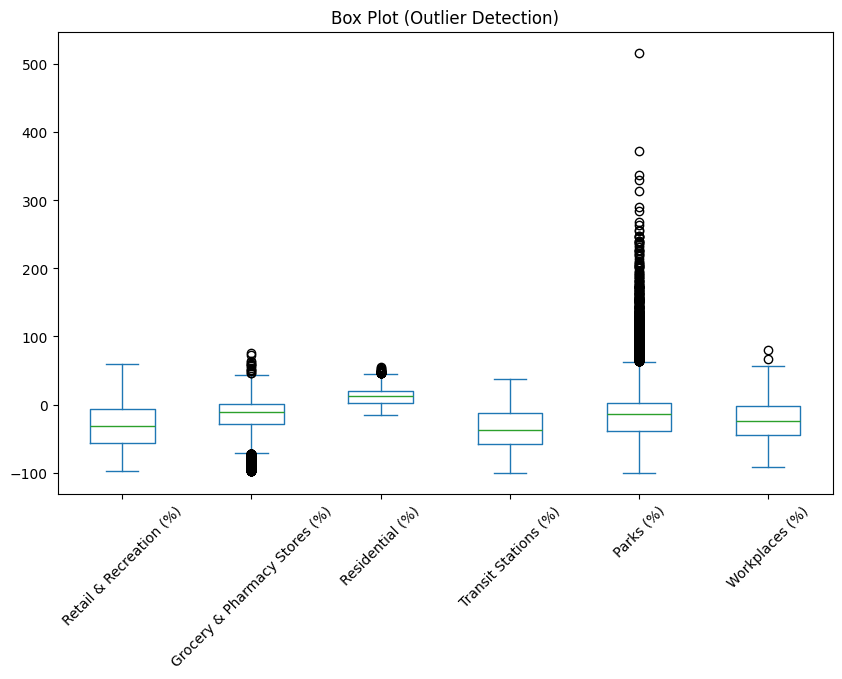

In [28]:
df.plot(kind='box', figsize=(10,6))
plt.title("Box Plot (Outlier Detection)")
plt.xticks(rotation=45)
plt.show()

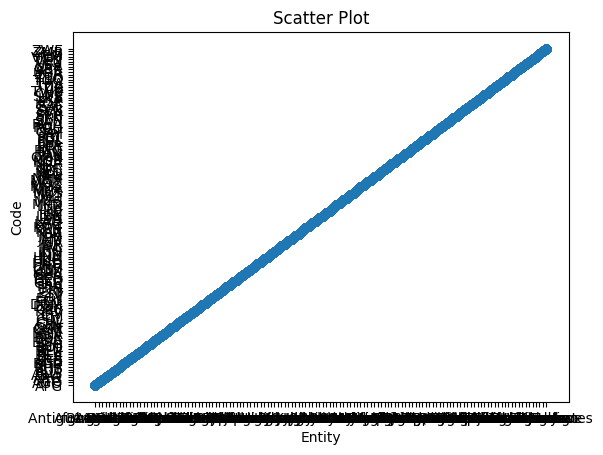

In [29]:
plt.scatter(df.iloc[:, 0], df.iloc[:, 1])
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title("Scatter Plot")
plt.show()

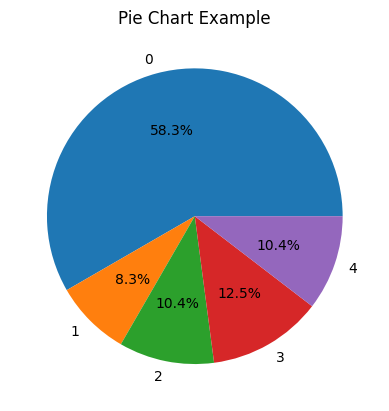

In [31]:
data = df.iloc[:5, -1].abs()

data.plot(kind='pie', autopct='%1.1f%%')
plt.title("Pie Chart Example")
plt.ylabel("")
plt.show()
